In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import UpROOT.io as io
import UpROOT.config as conf
import UpROOT.physics.delphes as ph
import UpROOT.plotting.delphes as pt
import UpROOT.pipelines.delphes as pl
import UpROOT.fitting.delphes as fi
import UpROOT.delphes_root as dr

In [3]:
DATASET01 = 'dimuons_70GeV'

In [4]:
collections = (
    'EFlowTrack',
    'Electron',
    'Event',
    'Jet',
    'Muon',
    'Particle',
    'Photon',
    'ScalarHT',
    'Track',
    'Weight'
)

In [5]:
io.load_dataframe(
    branches=io.txt_data("mpmm"),
    dataset=DATASET01,
).head()

Ramas cargadas desde: C:\Users\mario\Documents\PF\MadGraph\analysis\mpmm.txt
Cantidad de ramas: 33
Archivo: MG5_pp_dimuons_100k_70GeV_01.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_dimuons_100k_70GeV_02.root
Árbol seleccionado: Delphes
Archivo: MG5_pp_dimuons_100k_70GeV_03.root
Árbol seleccionado: Delphes
Total de eventos: 300,000 eventos


,Event/Event.CrossSection,Event/Event.CrossSectionError,Event/Event.Number,Event/Event.Weight,Jet/Jet.BTag,Jet/Jet.Charge,Jet/Jet.ChargedEnergyFraction,Jet/Jet.Constituents,Jet/Jet.Eta,Jet/Jet.Mass,...,Muon/Muon.IsolationVarRhoCorr,Muon/Muon.PT,Muon/Muon.Particle,Muon/Muon.Phi,Muon/Muon.SumPt,Muon/Muon.SumPtCharged,Muon/Muon.SumPtChargedPU,Muon/Muon.SumPtNeutral,Muon/Muon.T,Muon_size
0,[2.475590944290161],[61889.7734375],[0],[34456.97265625],[],[],[],[],[],[],...,[0.0],[1.0118755102157593],[{'ref': 33}],[0.8265688419342041],[0.0],[0.0],[0.0],[0.0],[4.963054411888379e-09],1
1,[4.951181888580322],[0.0],[1],[40291.40625],[],[],[],[],[],[],...,[],[],[],[],[],[],[],[],[],0
2,[7.4267730712890625],[0.000742599309887737],[2],[39689.8203125],[],[],[],[],[],[],...,"[0.0, 0.0]","[2.2332069873809814, 0.8086196184158325]","[{'ref': 15}, {'ref': 16}]","[-0.46595829725265503, -2.3684661388397217]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[6.611529101974156e-09, 8.747543134290936e-09]",2
3,[9.902363777160645],[0.0],[3],[33223.01171875],[],[],[],[],[],[],...,"[0.0, 0.0]","[1.972589135169983, 1.4718183279037476]","[{'ref': 249}, {'ref': 248}]","[-0.9489349126815796, -1.1402088403701782]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[0.0, 0.0]","[4.775023043634974e-09, 1.0535520011956123e-08]",2
4,[12.377955436706543],[0.0],[4],[33898.36328125],[],[],[],[],[],[],...,[0.0],[3.2188990116119385],[{'ref': 18}],[-0.782015860080719],[0.0],[0.0],[0.0],[0.0],[1.0312284359770274e-08],1


In [6]:
output = dr.convert_dataset(
    dataset=DATASET01,
    collections=collections,
    step_size='20 MB',
    object_registry=True,
    overwrite=True,
    create_dimuons=False
)

Ramas internas de ROOT excluidas:
 - EFlowNeutralHadron/EFlowNeutralHadron.fBits
 - EFlowPhoton/EFlowPhoton.fBits
 - EFlowTrack/EFlowTrack.fBits
 - Electron/Electron.fBits
 - Event/Event.fBits
 - FatJet/FatJet.fBits
 - GenJet/GenJet.fBits
 - GenMissingET/GenMissingET.fBits
 - Jet/Jet.fBits
 - MissingET/MissingET.fBits
 - Muon/Muon.fBits
 - Particle/Particle.fBits
 - Photon/Photon.fBits
 - ScalarHT/ScalarHT.fBits
 - Tower/Tower.fBits
 - Track/Track.fBits
 - Weight/Weight.fBits

Archivo de entrada: C:\Users\mario\Documents\PF\data\MG5_pp_dimuons_100k_70GeV_01.root
Eventos: 100,000
Colecciones: EFlowTrack, Electron, Jet, Muon, Particle, Photon, ScalarHT, Track, Weight
 EFlowTracks: 54 ramas; bloques de 20 MB
 Electrons: 18 ramas; bloques de 20 MB
 Jets: 46 ramas; bloques de 20 MB
 Muons: 17 ramas; bloques de 20 MB
 Particles: 23 ramas; bloques de 20 MB
 Photons: 15 ramas; bloques de 20 MB
 ScalarHT: 2 ramas; bloques de 20 MB
 Tracks: 54 ramas; bloques de 20 MB
 Weights: 2 ramas; bloques d

In [7]:
PDATASET01 = 'dimuons_70GeV_p'

In [8]:
cut = '(Eta < 5.0) & (Eta > 2)'

In [9]:
df_events = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Events'
)
df_events.head()

Archivo: dimuons_70GeV_pandas.root
Árbol seleccionado: Events
Total de eventos: 300,000 eventos


,source_file_id,event_id,source_entry,root_uid,event_number,ReadTime,ProcTime,ProcessID,MPI,event_weight,...,PDF2,n_EFlowTrack,n_Electron,n_Jet,n_Muon,n_Particle,n_Photon,n_ScalarHT,n_Track,n_Weight
0,0,0,0,0,0,0.193170,0.001548,9999,-1,34456.972656,...,0.0,5,0,0,1,171,0,1,5,292
1,0,1,1,0,1,0.002039,0.001988,9999,-1,40291.406250,...,0.0,5,0,0,0,463,0,1,5,292
2,0,2,2,0,2,0.000253,0.000223,9999,-1,39689.820312,...,0.0,3,0,0,2,93,0,1,3,292
3,0,3,3,0,3,0.001578,0.002683,9999,-1,33223.011719,...,0.0,16,0,0,2,740,0,1,16,292
4,0,4,4,0,4,0.000305,0.000293,9999,-1,33898.363281,...,0.0,3,0,0,1,120,0,1,3,292


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\event_multiplicities_70GeV_02.png.


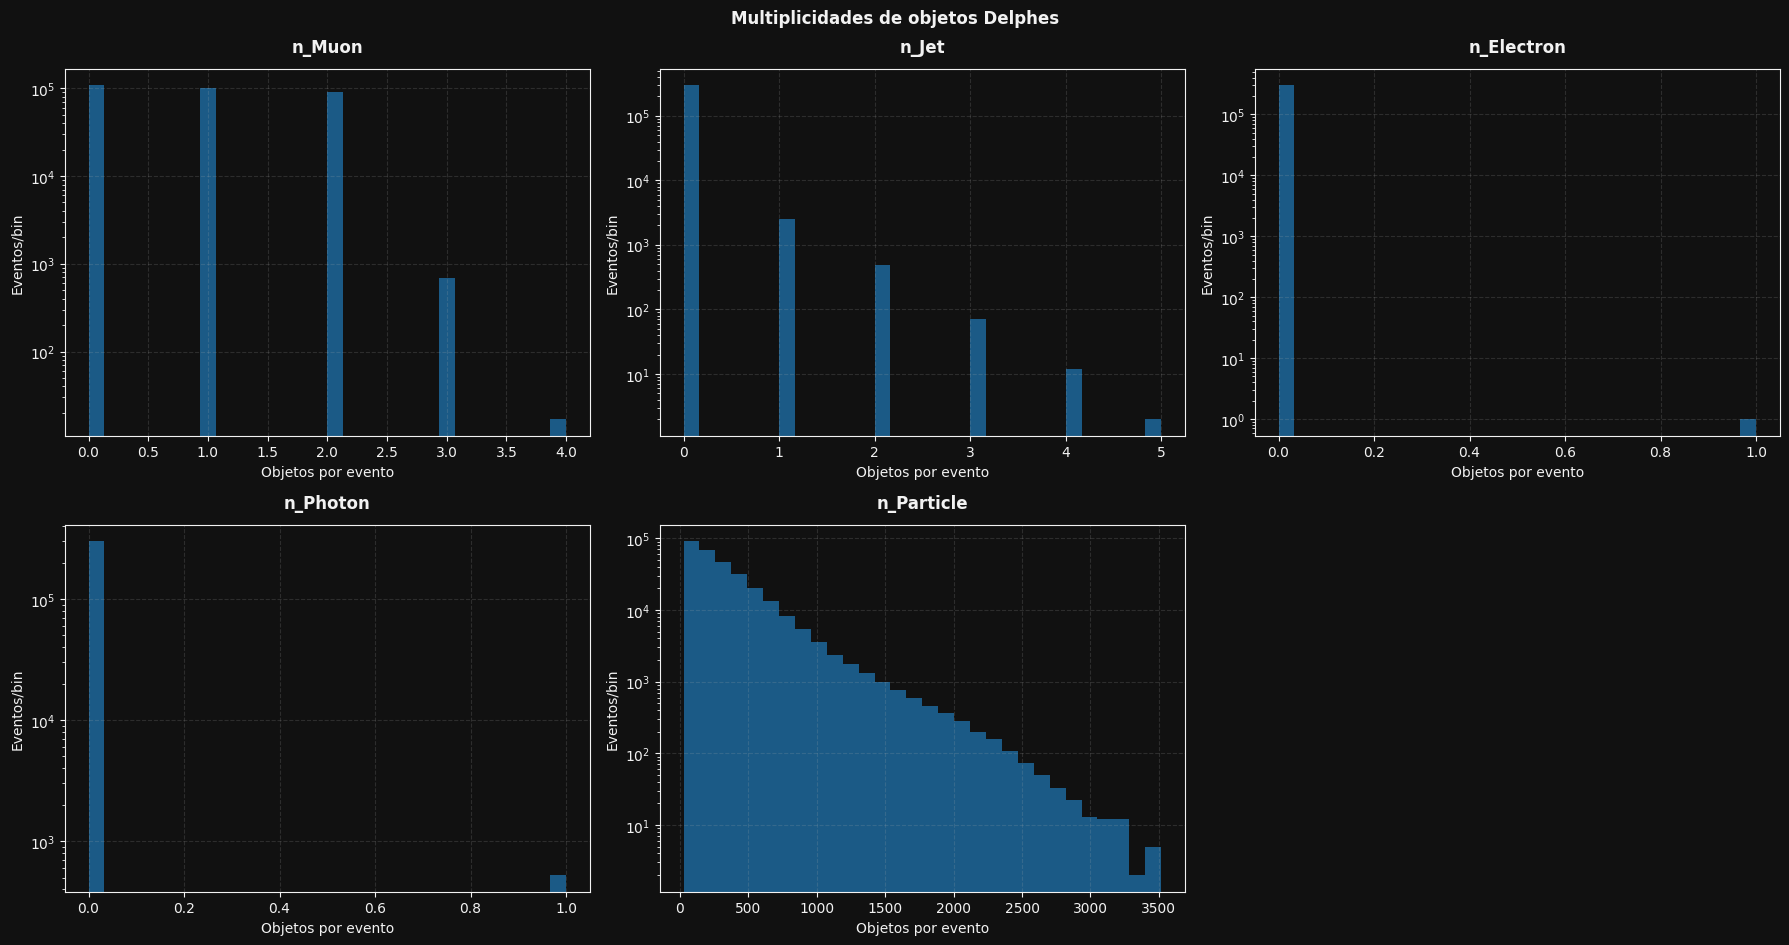

(<Figure size 1800x960 with 6 Axes>,
 array([[<Axes: title={'center': 'n_Muon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Jet'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Electron'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>],
        [<Axes: title={'center': 'n_Photon'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: title={'center': 'n_Particle'}, xlabel='Objetos por evento', ylabel='Eventos/bin'>,
         <Axes: >]], dtype=object))

In [10]:
pt.plot_event_multiplicities(
    df_events, 
    data='delphes03', 
    save=True, 
    filename='event_multiplicities_70GeV_02'
)

In [11]:
df_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons'
)
df_muons.head(7)

Archivo: dimuons_70GeV_pandas.root
Árbol seleccionado: Muons
Total de eventos: 283,300 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
0,0,0,0,0,254,1.011876,0.220297,0.826569,4.963054e-09,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
1,0,2,2,0,146,2.233207,0.968429,-0.465958,6.611529e-09,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.000000e+00,0.0,0.0
2,0,2,2,1,147,0.808620,1.030492,-2.368466,8.747543e-09,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0
3,0,3,3,0,990,1.972589,-0.403514,-0.948935,4.775023e-09,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,-8.094409e-14,0.0,0.0
4,0,3,3,1,989,1.471818,1.832349,-1.140209,1.053552e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.000000e+00,0.0,0.0
5,0,4,4,0,186,3.218899,2.099392,-0.782016,1.031228e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.000000e+00,0.0,0.0
6,0,6,6,0,935,4.066481,-2.118665,1.062907,1.030048e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.000000e+00,0.0,0.0


In [12]:
cdf_muons = io.load_dataframe(
    branches=None,
    dataset=PDATASET01,
    tree_path='Muons',
    cut=cut
)
cdf_muons.head(7)

Archivo: dimuons_70GeV_pandas.root
Árbol seleccionado: Muons
Total de eventos: 26,555 eventos


,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,IsolationVar,IsolationVarRhoCorr,SumPtCharged,SumPtNeutral,SumPtChargedPU,SumPt,D0,DZ,ErrorD0,ErrorDZ
5,0,4,4,0,186,3.218899,2.099392,-0.782016,1.031228e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
14,0,10,10,1,152,1.239119,2.343503,2.138096,1.019436e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
57,0,62,62,0,453,2.133362,2.004426,-0.988104,1.037786e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
60,0,65,65,0,1446,1.683007,2.148878,-1.254118,1.028389e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,-0.0,0.0,0.0,0.0
64,0,69,69,0,673,1.057010,2.435150,-2.715881,1.016318e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
74,0,83,83,0,766,1.717772,2.294924,-1.584375,1.021302e-08,1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
75,0,85,85,0,149,1.187777,2.463034,2.763013,1.015425e-08,-1,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_70GeV_01.png.


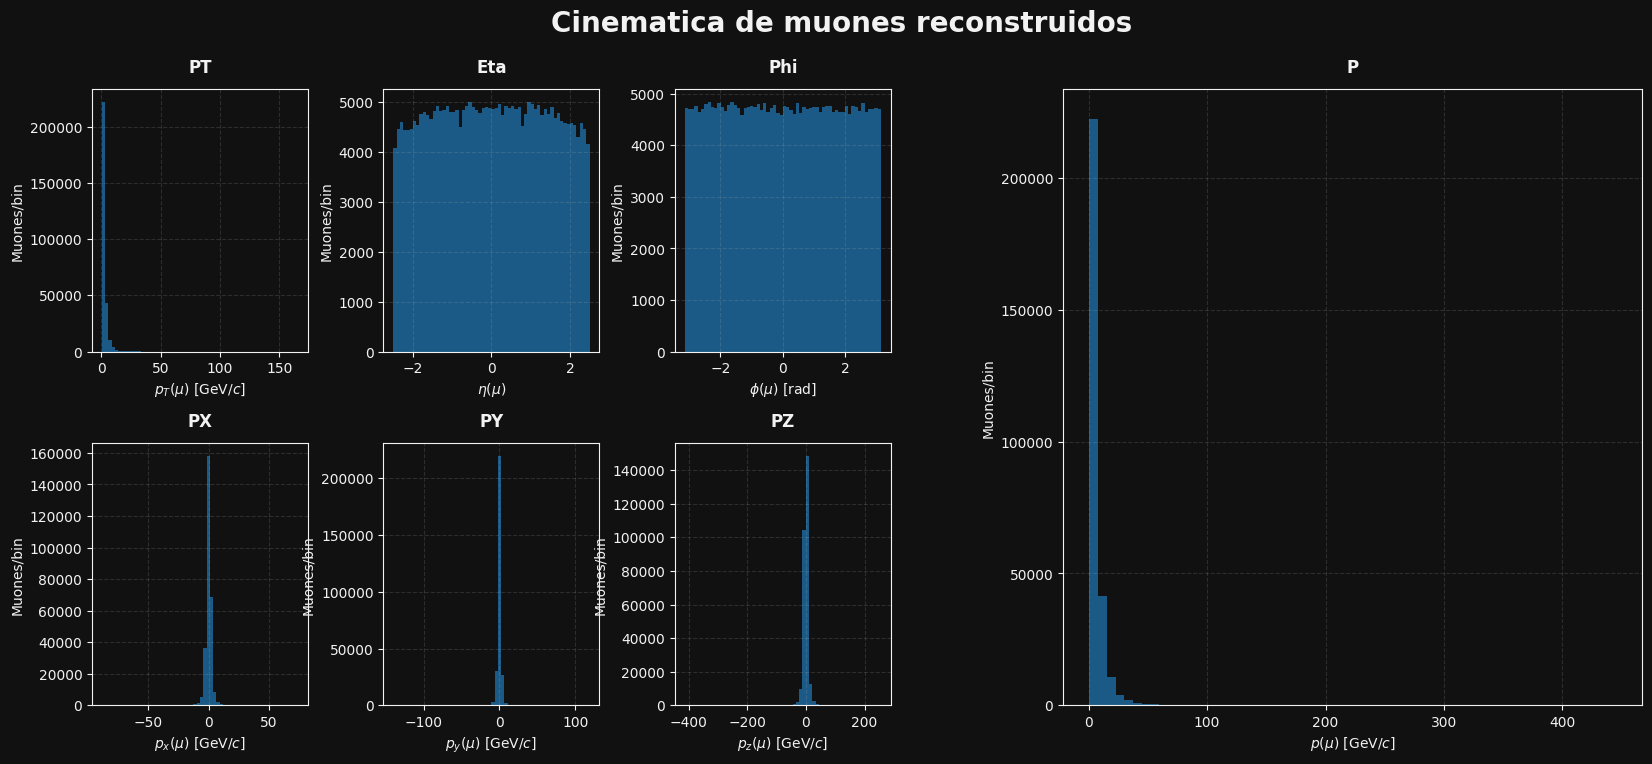

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [13]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_70GeV_01"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_70GeV_01_cut.png.


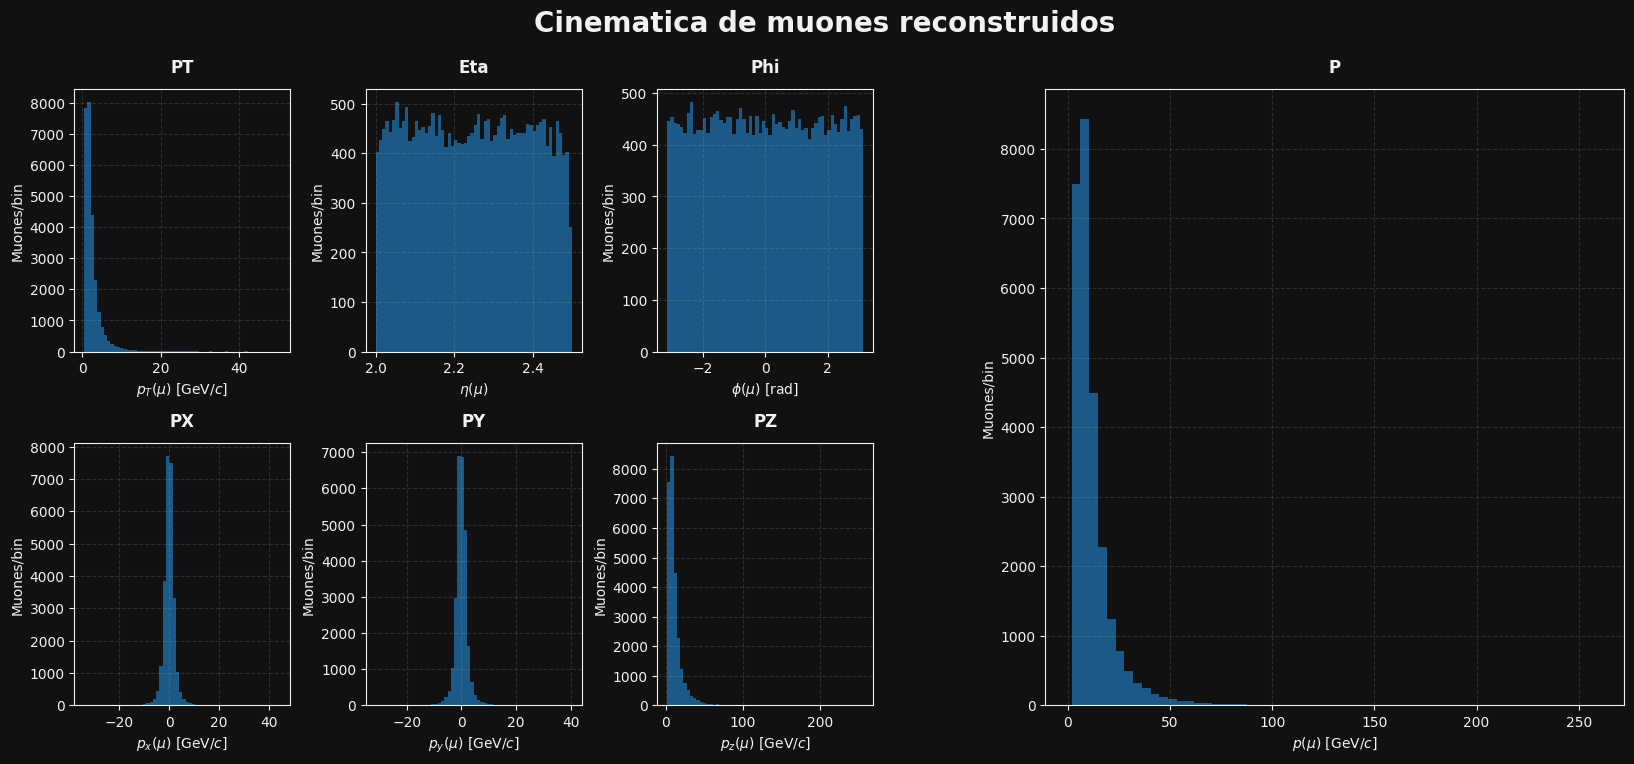

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [14]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_70GeV_01_cut"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_70GeV_02.png.


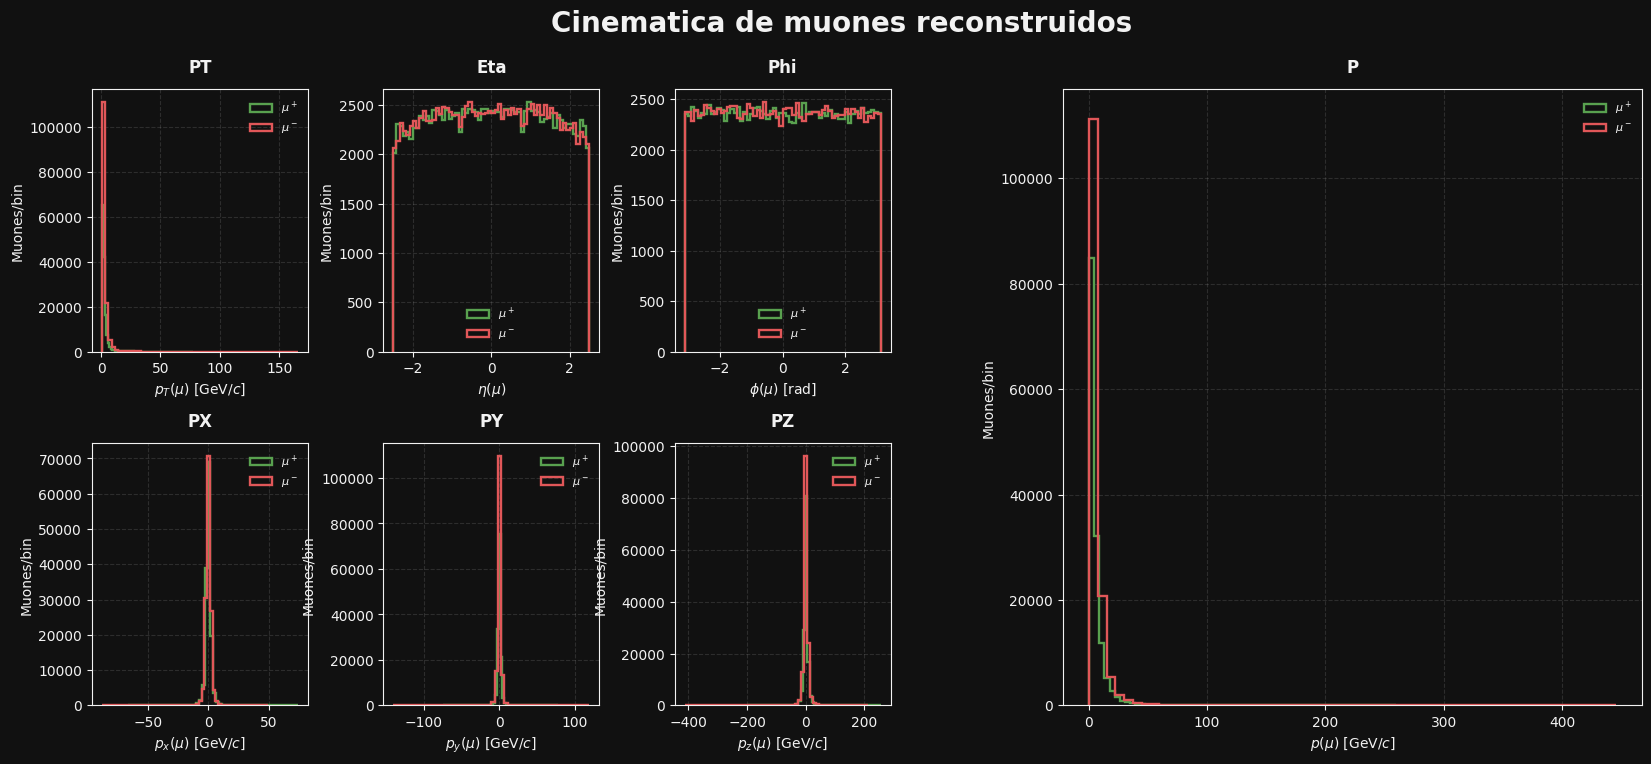

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [15]:
pt.plot_muon_kinematics(
    df_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_70GeV_02"
)

c:\Users\mario\Documents\PF\MadGraph\UpROOT\styles.py:145: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\muon_kinematics_70GeV_02_cut.png.


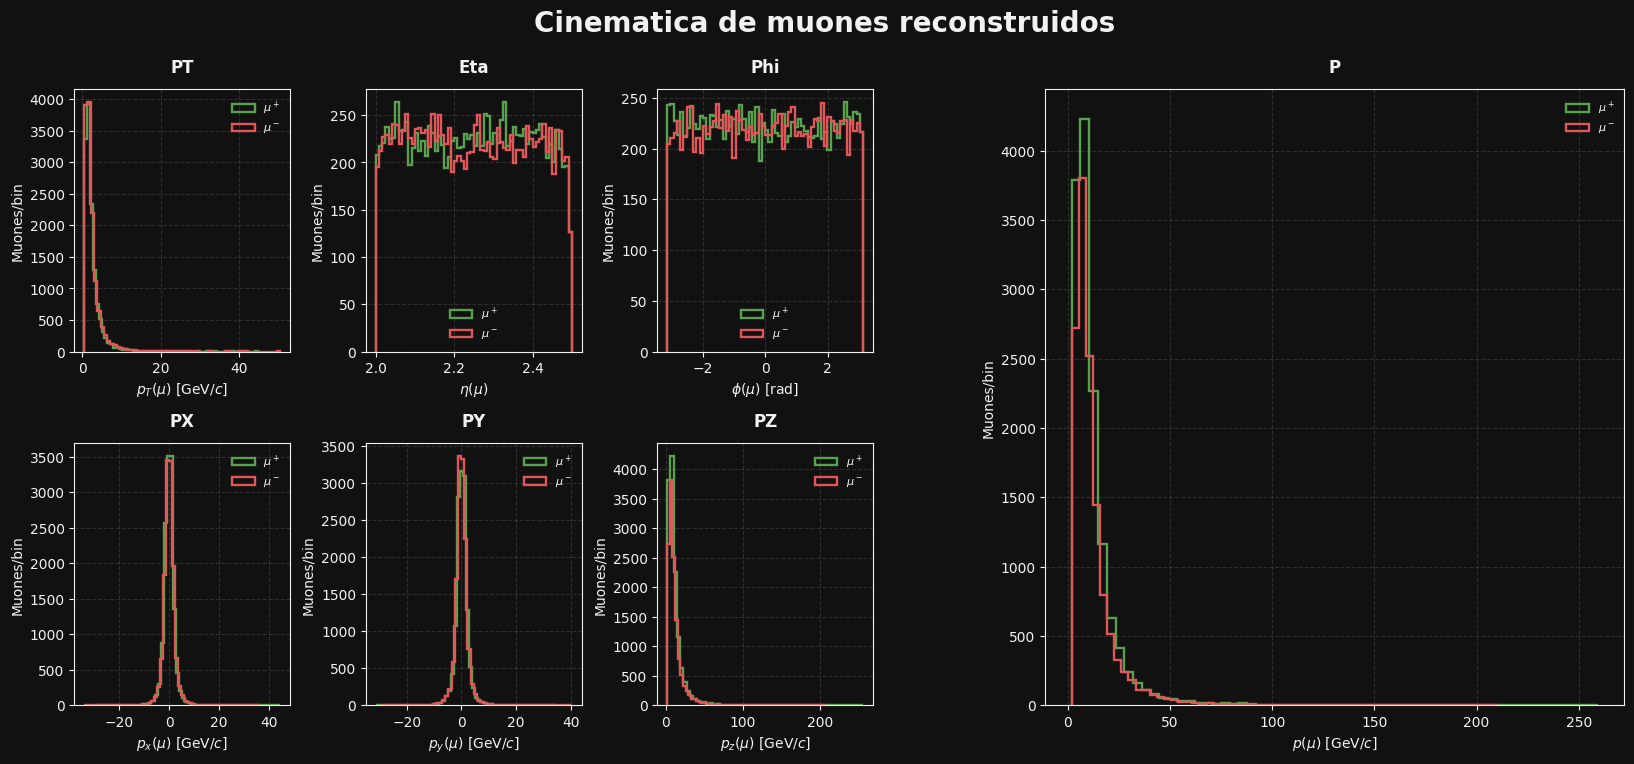

(<Figure size 2000x800 with 7 Axes>,
 {'PT': <Axes: title={'center': 'PT'}, xlabel='$p_T(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'Eta': <Axes: title={'center': 'Eta'}, xlabel='$\\eta(\\mu)$', ylabel='Muones/bin'>,
  'Phi': <Axes: title={'center': 'Phi'}, xlabel='$\\phi(\\mu)$ [rad]', ylabel='Muones/bin'>,
  'PX': <Axes: title={'center': 'PX'}, xlabel='$p_x(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PY': <Axes: title={'center': 'PY'}, xlabel='$p_y(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'PZ': <Axes: title={'center': 'PZ'}, xlabel='$p_z(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>,
  'P': <Axes: title={'center': 'P'}, xlabel='$p(\\mu)$ [GeV/$c$]', ylabel='Muones/bin'>})

In [16]:
pt.plot_muon_kinematics(
    cdf_muons, 
    bins=60, 
    split_charge=True, 
    data='delphes03', 
    save=True, 
    filename="muon_kinematics_70GeV_02_cut"
)

In [17]:
df_muons = ph.calc_four_momentum(df_muons)
df_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
0,0,0,0,0,254,1.011876,0.220297,0.826569,4.963054e-09,-1,...,0.0,0.0,0.000000e+00,0.0,0.0,0.685448,0.744347,0.224720,1.036528,1.041900
1,0,2,2,0,146,2.233207,0.968429,-0.465958,6.611529e-09,1,...,0.0,-0.0,0.000000e+00,0.0,0.0,1.995128,-1.003333,2.516965,3.364866,3.366525
2,0,2,2,1,147,0.808620,1.030492,-2.368466,8.747543e-09,-1,...,0.0,0.0,0.000000e+00,0.0,0.0,-0.578754,-0.564721,0.988786,1.277326,1.281689
3,0,3,3,0,990,1.972589,-0.403514,-0.948935,4.775023e-09,-1,...,0.0,-0.0,-8.094409e-14,0.0,0.0,1.149130,-1.603312,-0.817744,2.135372,2.137984
4,0,3,3,1,989,1.471818,1.832349,-1.140209,1.053552e-08,1,...,0.0,-0.0,0.000000e+00,0.0,0.0,0.614344,-1.337472,4.480591,4.716136,4.717320


In [18]:
cdf_muons = ph.calc_four_momentum(cdf_muons)
cdf_muons.head()

,source_file_id,event_id,source_entry,object_index,root_uid,PT,Eta,Phi,T,Charge,...,SumPt,D0,DZ,ErrorD0,ErrorDZ,PX,PY,PZ,P,E
5,0,4,4,0,186,3.218899,2.099392,-0.782016,1.031228e-08,1,...,0.0,-0.0,0.0,0.0,0.0,2.283791,-2.268394,12.937841,13.332256,13.332675
14,0,10,10,1,152,1.239119,2.343503,2.138096,1.019436e-08,-1,...,0.0,0.0,0.0,0.0,0.0,-0.665849,1.045017,6.394891,6.513835,6.514692
57,0,62,62,0,453,2.133362,2.004426,-0.988104,1.037786e-08,1,...,0.0,-0.0,0.0,0.0,0.0,1.173933,-1.781323,7.773009,8.060453,8.061145
60,0,65,65,0,1446,1.683007,2.148878,-1.254118,1.028389e-08,1,...,0.0,-0.0,0.0,0.0,0.0,0.524108,-1.599319,7.117954,7.314218,7.314981
64,0,69,69,0,673,1.057010,2.435150,-2.715881,1.016318e-08,1,...,0.0,0.0,0.0,0.0,0.0,-0.962667,-0.436512,5.987935,6.080513,6.081431


In [19]:
df_dimuons = ph.prepare_dimuon_analysis(df_muons, events=df_events)
df_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,2,0,146,2.233207,0.968429,-0.465958,6.611529e-09,1,15,0.0,...,0.982659,0.031021,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,3,1,989,1.471818,1.832349,-1.140209,1.053552e-08,1,248,0.0,...,0.596156,-0.806848,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,6,0,935,4.066481,-2.118665,1.062907,1.030048e-08,1,256,0.0,...,-1.629703,0.718260,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,7,1,446,1.160965,0.591886,-2.249397,5.514324e-09,1,77,0.0,...,-0.169319,-0.571428,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,8,0,784,2.296106,-0.933983,2.601437,6.438107e-09,1,176,0.0,...,-0.996100,-0.128690,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
5,10,0,151,1.436413,1.568087,-2.192398,1.092086e-08,1,15,0.0,...,1.925740,0.369383,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
6,13,0,197,2.244161,1.559841,-0.635034,1.088684e-08,1,15,0.0,...,1.328084,-0.341574,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


In [20]:
cdf_dimuons = ph.prepare_dimuon_analysis(cdf_muons, events=df_events)
cdf_dimuons.head(7)

,event_id,muplus_index,muplus_root_uid,muplus_pt,muplus_eta,muplus_phi,muplus_t,muplus_charge,muplus_particle_ref,muplus_isolation,...,dimuon_rapidity,cos_theta_star,muplus_d0_significance,muminus_d0_significance,muplus_chi2_ip_proxy,muminus_chi2_ip_proxy,sqrt_min_chi2_ip_proxy,min_chi2_ip_proxy,ip_proxy_valid,displacement_category
0,275,0,386,1.991969,2.425065,0.000024,1.016526e-08,1,85,0.0,...,2.276344,-0.176913,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
1,466,0,143,2.114987,2.105902,-1.317959,1.030871e-08,1,18,0.0,...,2.110730,0.006644,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
2,992,1,401,2.628878,2.105511,1.096751,1.030869e-08,1,42,0.0,...,2.151883,0.039992,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
3,1210,1,1399,1.552100,2.174505,-3.016491,1.027000e-08,1,786,0.0,...,2.246565,0.048405,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
4,1417,1,158,1.985537,2.408545,2.713352,1.017058e-08,1,22,0.0,...,2.188086,-0.152019,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
5,1598,1,686,1.152118,2.480584,-1.540932,1.014929e-08,1,145,0.0,...,2.285061,-0.141464,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid
6,1703,1,354,2.148206,2.194278,2.172627,1.025918e-08,1,73,0.0,...,2.296008,0.097185,NaN,NaN,NaN,NaN,NaN,NaN,False,invalid


Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\dimuon_mass_70GeV_01.png.


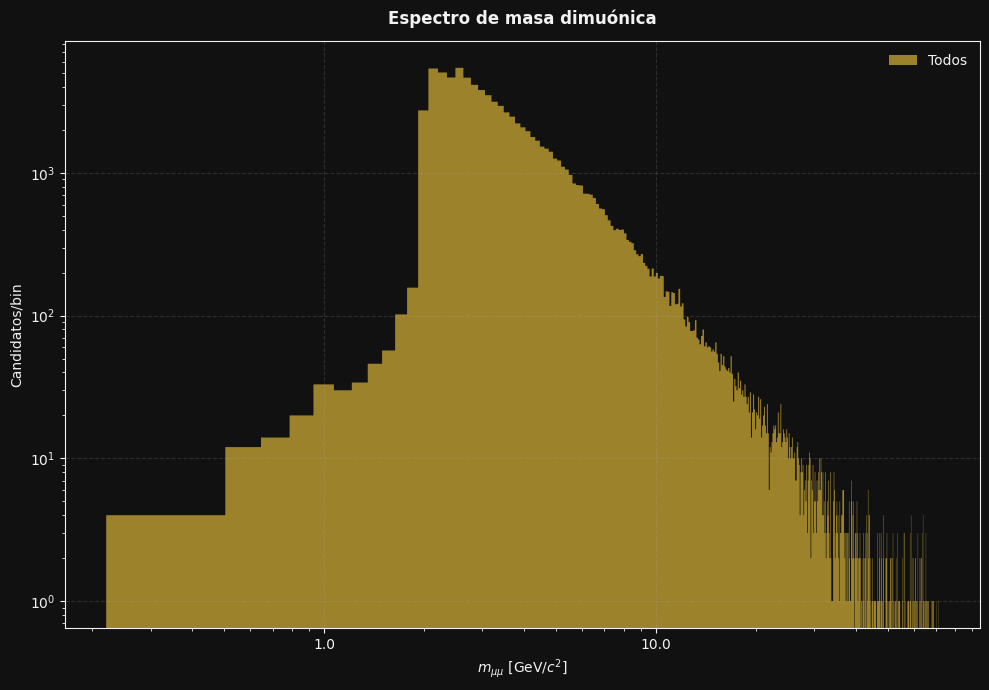

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [21]:
pt.plot_dimuon_mass(
    df_dimuons, 
    bins=500, 
    save=True, 
    log_x=True,
    log_y=True, 
    data='delphes03', 
    filename="dimuon_mass_70GeV_01"
)

Guardado en: C:\Users\mario\Documents\PF\MadGraph\assset\images\delphes\c03\dimuon_mass_70GeV_01_cut.png.


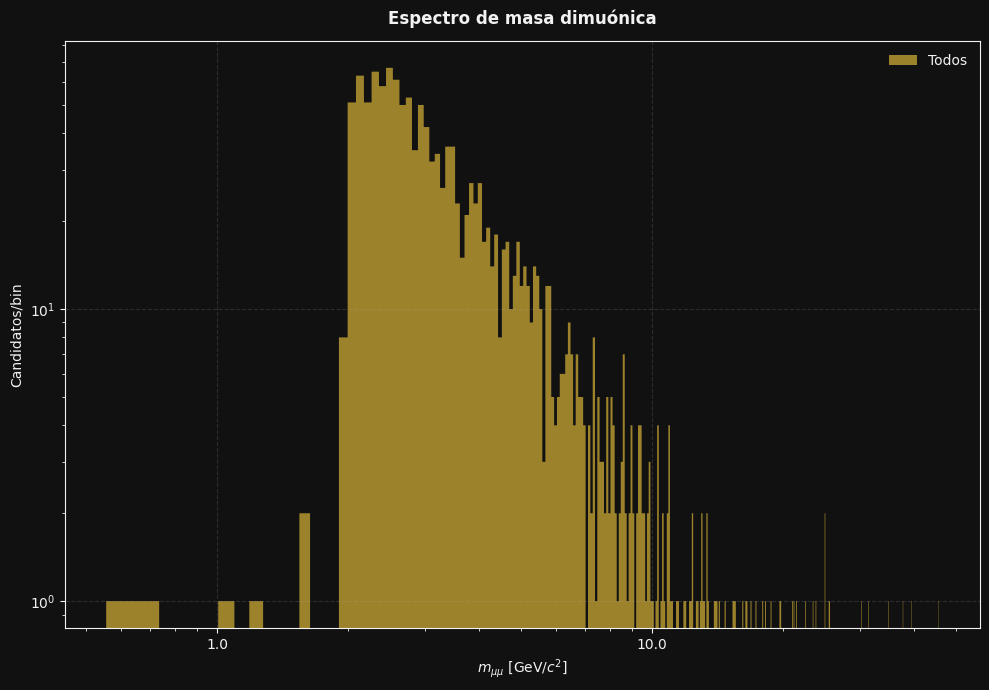

(<Figure size 1000x700 with 1 Axes>,
 <Axes: title={'center': 'Espectro de masa dimuónica'}, xlabel='$m_{\\mu\\mu}$ [GeV/$c^2$]', ylabel='Candidatos/bin'>)

In [22]:
pt.plot_dimuon_mass(
    cdf_dimuons, 
    bins=500, 
    save=True, 
    log_x=True,
    log_y=True, 
    data='delphes03', 
    filename="dimuon_mass_70GeV_01_cut"
)